# Tarea 3


## Objetivos

a) Entender conceptos y diferencia entre empuje de una aeronave y su potencia.

b) Determinar las curvas características de empuje y potencia disponible y requerido.

c) Encontrar las velocidades que corresponden al mínimo empuje y a la mínima potencia necesaria de una aeronave específica

d) Graficar múltiples datos de medición en un solo diagrama.

## Actividad 1

 A cada condición de vuelo (peso, altura, velocidad, etc.) corresponde un empuje y una potencia para lograr un vuelo recto y nivelado a velocidad constante. Se debe determinar el empuje y la potencia requerida de la aeronave Cessna 172 para todo su rango de velocidad (vel. máxima – vel. Mínima) a una altura constante de H=1000 ft y un peso W=2200lbf. CONSEJO: Para alcanzar la velocidad mínima, es recomendable desactivar el autopiloto de la aeronave y realizar el vuelo de forma manual. El autopiloto mantiene un márgen de seguridad con la velocidad mínima, para no entrar en STALL.

In [3]:
v_min = 47  * 1.688     #[ft/s]
v_max = 163 * 1.688     #[ft/s]
rho_1000ft = 0.00230839 #[slug/ft3] Digital Dutch
rho_0ft = 0.00237717    #[slug/ft3] Digital Dutch
W = 2200                #[lb]
S_w = 188               #[ft2]
b = 36+1/12             #[ft]
e = 0.75
c_d0 = 0.03
c_d0_L = 0.07

T_A_0 = 600             #[lb]

In [4]:
from numpy import pi, linspace

def T_req(v):
    return (.5*rho_1000ft*c_d0*v**2/(W/S_w) + c_d0_L + (W/S_w)/(.5*rho_1000ft*v**2*pi*e*(b**2/S_w)))*W

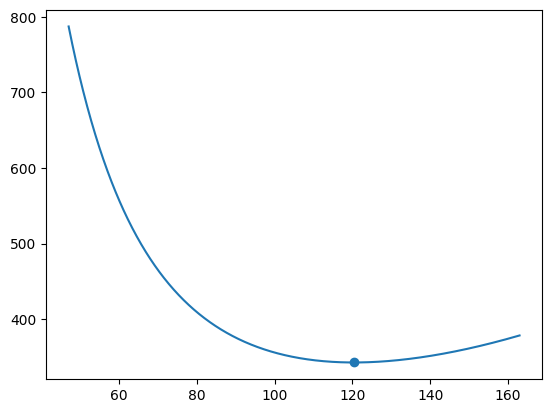

In [5]:
import matplotlib.pyplot as plt

v_linspace = linspace(v_min/1.688, v_max/1.688, 1000)
v_md = (4/(pi*e*(b**2/S_w)*c_d0))**.25 * ((W/S_w)/rho_1000ft)**.5

plt.plot(v_linspace, T_req(v_linspace))
plt.scatter([v_md], [T_req(v_md)])

In [6]:
print(T_req(v_min), T_req(v_max))

412.1437588879157 664.8647264436074


## Actividad 2
El motor de una aeronave, en combinación con su hélice, genera una cierta potencia y un empuje disponible. Ambos dependen de la velocidad de avance de la aeronave. Se debe medir la potencia y empuje disponible de la aeronave Cessna 172 en las mismas condiciones de vuelo que en la actividad 1.

Grafique los resultados de todos los valores medidos (potencia requerida, potencia disponible, empuje requerido, empuje disponible) en un solo diagrama sobre la velocidad indicada. Se debe identificar cada uno de los cuatro trazos de forma clara sin utilizar color como medio distintivo. Incluya funciones de aproximación de grado apropiado para cada una de las series. Justifíque la elección del grado de la función de aproximación.

Determine las velocidades que corresponden al mínimo del empuje necesario y al mínimo de la potencia necesaria. Calcule la relación entre ambas velocidades (cociente).

In [9]:
import numpy as np
import matplotlib.pyplot as plt
datos = []
with open('segundo_vuelo.csv', 'r') as archivo:
    next(archivo)                                  # saltar encabezado
    for linea in archivo:
        campos = linea.strip().split(';')
        try:
            fila = [float(c) for c in campos[:30]]  # 30 columnas de datos
        except ValueError:
            continue
        datos.append(fila)

datos = np.array(datos)
print(datos.shape)          # (filas, 30)

v_indicated_2 = datos[:, 0]   # [kt]
v_true_2      = datos[:, 2]   # [kt]
alpha_2       = datos[:, 7]   # [deg]
vpath_2       = datos[:, 10]  # [deg]
altitude_2    = datos[:, 14]  # [ft]
power_av_2    = datos[:, 20]  # [hp]
thrust_av_2   = datos[:, 21]  # [lb]
lift_2        = datos[:, 24]  # [lb]
drag_2        = datos[:, 25]  # [lb]

# print(len(thrust_av), thrust_av[:5])

(450, 30)


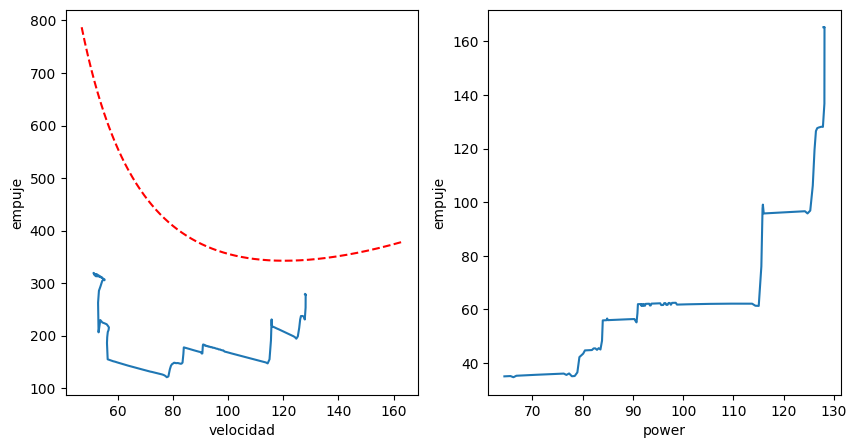

In [10]:
plt.rcParams['figure.figsize'] = (10,5)
fig, (ax1, ax2) = plt.subplots(1,2)
ax1.plot(v_true_2[150:-10],thrust_av_2[150:-10])
ax1.set_ylabel('empuje')
ax1.set_xlabel('velocidad')

ax1.plot(v_linspace, T_req(v_linspace), linestyle='--', color='red')

ax2.plot(v_true_2[150:-50],power_av_2[150:-50])
ax2.set_xlabel('power')
ax2.set_ylabel('empuje')
plt.show()

In [11]:

datos = []
with open('primer_vuelo.csv', 'r') as archivo:   # revisa que el nombre coincida con tu archivo
    next(archivo)                                 # saltar encabezado
    for linea in archivo:
        campos = linea.strip().split(';')
        try:
            fila = [float(c) for c in campos[:31]]   # 31 columnas de datos
        except ValueError:
            continue                                  # salta líneas vacías o cortadas
        datos.append(fila)

datos = np.array(datos)

v_indicated_1 = datos[:, 0]    # [kt]  _kias
v_true_1      = datos[:, 2]    # [kt]  _ktas
altitude_1    = datos[:, 21]   # [ft]  MSL
power_av_1    = datos[:, 27]   # [hp]  potencia
thrust_av_1   = datos[:, 28]   # [lb]  empuje

print(len(datos)) 

623


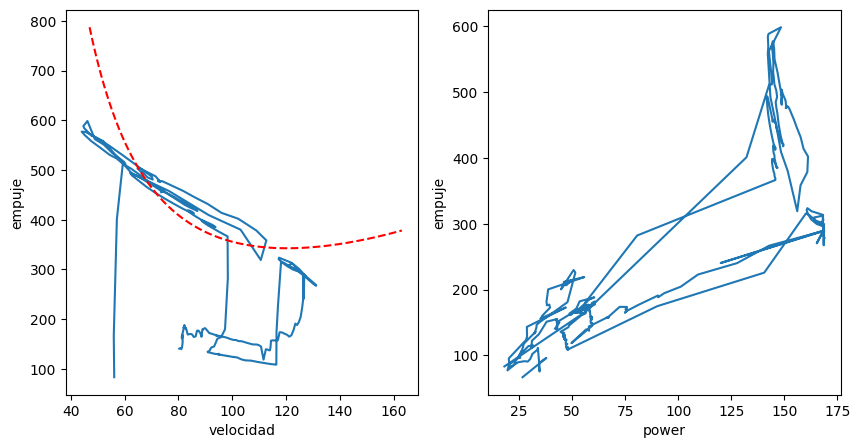

In [12]:
plt.rcParams['figure.figsize'] = (10,5)
fig, (ax1, ax2) = plt.subplots(1,2)
ax1.plot(v_true_1[0:100 and 500:],thrust_av_1[0:100 and 500:])
ax1.set_ylabel('empuje')
ax1.set_xlabel('velocidad')

ax1.plot(v_linspace, T_req(v_linspace), linestyle='--', color='red')

ax2.plot(power_av_1,thrust_av_1)
ax2.set_xlabel('power')
ax2.set_ylabel('empuje')
plt.show()

## c_L y c_D para condicion de vuelo

In [13]:
with open('vuelo_3.csv', 'r') as archivo:
    lineas = [line.rstrip(',') for line in archivo]

v_indicated_3 = []    # [kt]  _kias
v_true_3      = []    # [kt]  _ktas
altitude_3    = []   # [ft]  MSL
throttle_3    = []   # [%]  potencia
power_av_3    = []   # [hp]  potencia
thrust_av_3   = []   # [lb]  empuje
c_d           = []   # [-]  coeficiente de arrastre
c_l           = []   # [-]  coeficiente de sustentación
# print(lineas[1].split(';')[7])

for i in lineas[1:-1]:
    v_indicated_3.append(float(i.split(';')[7]))
    v_true_3.append(float(i.split(';')[9]))
    altitude_3.append(float(i.split(';')[21]))
    throttle_3.append(float(i.split(';')[27]))
    power_av_3.append(float(i.split(';')[29]))
    thrust_av_3.append(float(i.split(';')[30]))
    c_d.append(float(i.split(';')[39]))
    c_l.append(float(i.split(';')[40]))

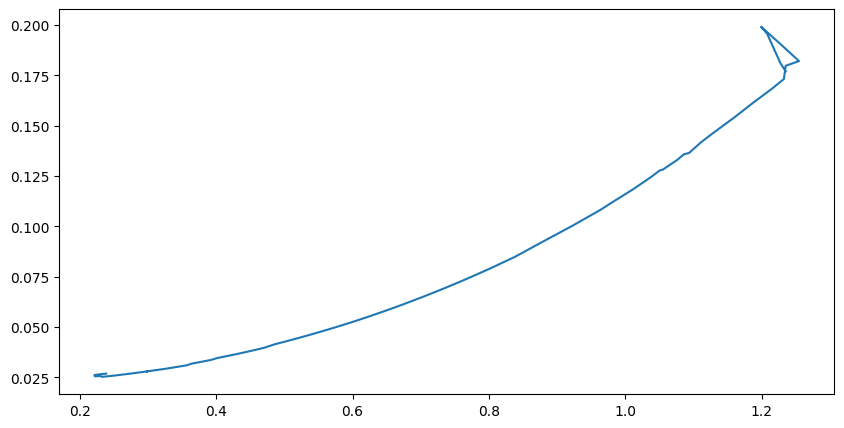

In [14]:
plt.plot(c_d, c_l)

In [15]:
with open('vuelo_3.csv', 'r') as archivo:
    lineas = [line.rstrip(',') for line in archivo]

v_indicated_3 = []    # [kt]  _kias
v_true_3      = []    # [kt]  _ktas
altitude_3    = []   # [ft]  MSL
throttle_3    = []   # [%]  potencia
power_av_3    = []   # [hp]  potencia
thrust_av_3   = []   # [lb]  empuje
# print(lineas[1].split(';')[7])

for i in lineas[1:-1]:
    v_indicated_3.append(float(i.split(';')[7]))
    v_true_3.append(float(i.split(';')[9]))
    altitude_3.append(float(i.split(';')[21]))
    throttle_3.append(float(i.split(';')[27]))
    power_av_3.append(float(i.split(';')[29]))
    thrust_av_3.append(float(i.split(';')[30]))


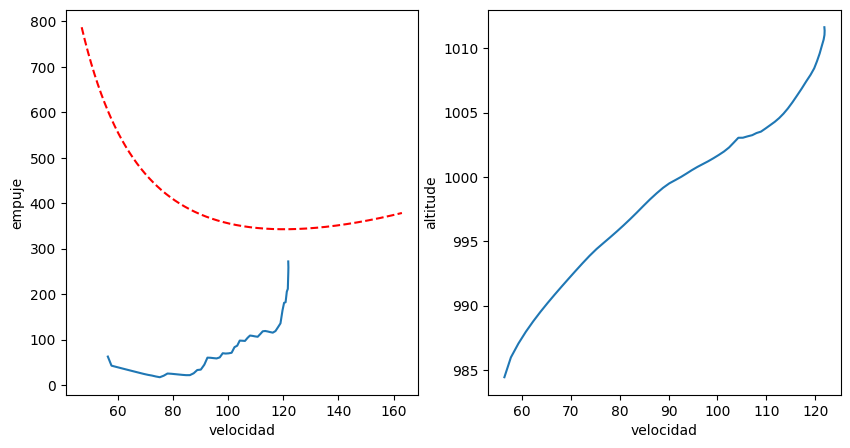

In [16]:
plt.rcParams['figure.figsize'] = (10,5)
fig, (ax1, ax2) = plt.subplots(1,2)
ax1.plot(v_true_3[10:-20],thrust_av_3[10:-20])
ax1.set_ylabel('empuje')
ax1.set_xlabel('velocidad')

ax1.plot(v_linspace, T_req(v_linspace), linestyle='--', color='red')

ax2.plot(v_true_3[10:-20],altitude_3[10:-20])
ax2.set_ylabel('altitude')
ax2.set_xlabel('velocidad')
plt.show()

In [17]:
with open('vuelo_4.csv', 'r') as archivo:
    lineas = [line.rstrip(',') for line in archivo]

v_indicated_4 = []    # [kt]  _kias
v_true_4      = []    # [kt]  _ktas
altitude_4    = []   # [ft]  MSL
throttle_4    = []   # [%]  potencia
power_av_4    = []   # [hp]  potencia
thrust_av_4   = []   # [lb]  empuje
# print(lineas[1].split(';')[7])

for i in lineas[1:-1]:
    v_indicated_4.append(float(i.split(';')[7]))
    v_true_4.append(float(i.split(';')[9]))
    altitude_4.append(float(i.split(';')[21]))
    throttle_4.append(float(i.split(';')[27]))
    power_av_4.append(float(i.split(';')[29]))
    thrust_av_4.append(float(i.split(';')[30]))

thr_av=max(thrust_av_4[0:40])
loc=thrust_av_4.index(thr_av)
print(loc)
print(thr_av)
pwe_av=power_av_4[loc]
print(pwe_av)

17
406.1958
150.19696


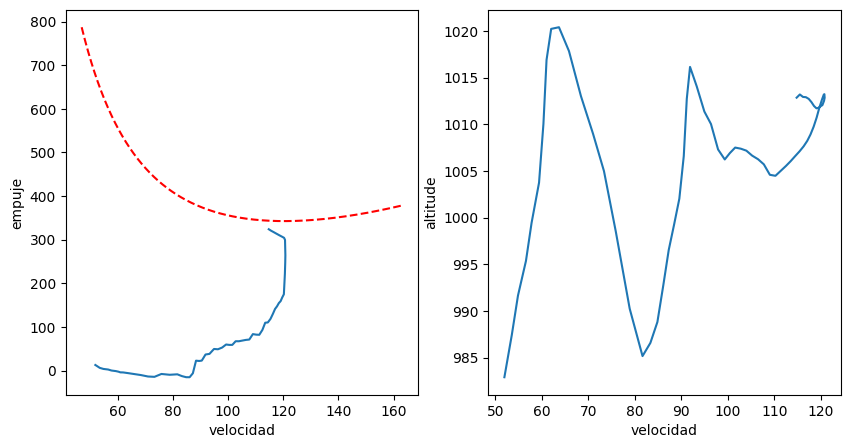

In [18]:
plt.rcParams['figure.figsize'] = (10,5)
fig, (ax1, ax2) = plt.subplots(1,2)
ax1.plot(v_true_4[65:-15],thrust_av_4[65:-15])
ax1.set_ylabel('empuje')
ax1.set_xlabel('velocidad')

ax1.plot(v_linspace, T_req(v_linspace), linestyle='--', color='red')

ax2.plot(v_true_4[65:-15],altitude_4[65:-15])
ax2.set_ylabel('altitude')
ax2.set_xlabel('velocidad')
plt.show()

In [19]:
with open('vuelo_5.csv', 'r') as archivo:
    lineas = [line.rstrip(',') for line in archivo]

v_indicated_5 = []    # [kt]  _kias
v_true_5      = []    # [kt]  _ktas
altitude_5    = []   # [ft]  MSL
throttle_5    = []   # [%]  potencia
power_av_5    = []   # [hp]  potencia
thrust_av_5   = []   # [lb]  empuje
# print(lineas[1].split(';')[7])

for i in lineas[1:-1]:
    v_indicated_5.append(float(i.split(';')[7]))
    v_true_5.append(float(i.split(';')[9]))
    altitude_5.append(float(i.split(';')[21]))
    throttle_5.append(float(i.split(';')[27]))
    power_av_5.append(float(i.split(';')[29]))
    thrust_av_5.append(float(i.split(';')[30]))


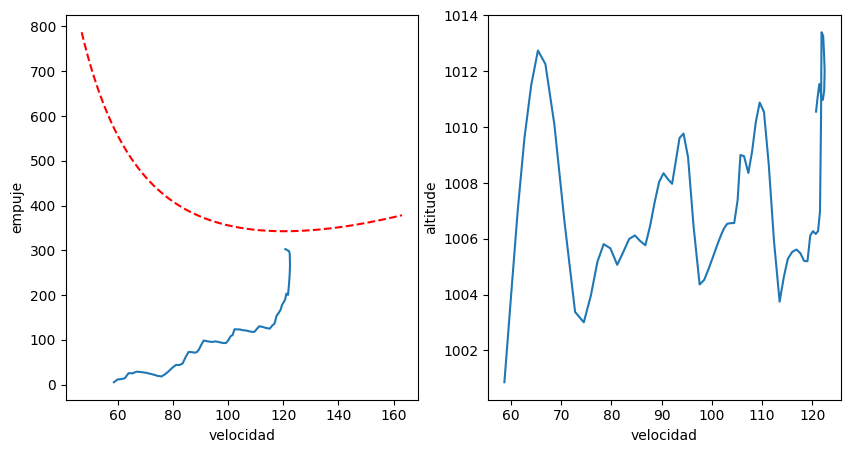

In [20]:
plt.rcParams['figure.figsize'] = (10,5)
fig, (ax1, ax2) = plt.subplots(1,2)
ax1.plot(v_true_5[68:-30],thrust_av_5[68:-30])
ax1.set_ylabel('empuje')
ax1.set_xlabel('velocidad')

ax1.plot(v_linspace, T_req(v_linspace), linestyle='--', color='red')

ax2.plot(v_true_5[68:-30],altitude_5[68:-30])
ax2.set_ylabel('altitude')
ax2.set_xlabel('velocidad')
plt.show()